# Lab: Data Visualization and Visual Thinking

The U.S. Bureau of Transportation Statistics collects information about scheduled domestic flights. In this lab, you will use the ideas from **Data Visualization and Visual Thinking** to examine a documented sample of 5,000 completed, non-diverted flights from May 2026.


## Learning goals

By the end of this lab, you should be able to:

- load and inspect a CSV file as a Pandas DataFrame;
- distinguish Pandas data types from quantitative and categorical feature types;
- check for missing values;
- create and label a histogram and a bar chart;
- describe a distribution by its typical values, range, and skew;
- use `.describe()` to check estimates made from a histogram;
- explain how histogram bins and axis scales affect a figure; and
- identify conclusions that can and cannot be supported by a sample; and
- find a documented dataset, audit every feature, and interpret its quantitative and categorical distributions.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You are still responsible for understanding every part of your submission and checking suggestions against your notebook's output. At the end of the lab, disclose whether you used an AI tool and how you evaluated its advice.


## Dataset

The [U.S. Bureau of Transportation Statistics (BTS) Reporting Carrier On-Time Performance data](https://www.transtats.bts.gov/DL_SelectFields.aspx?QO_fu146_anzr=b0-gvzr&gnoyr_VQ=FGJ) contains 611,735 reported domestic flight records for May 2026. Completed, non-diverted flights with recorded values for all five selected features were eligible for this lab. Canceled flights, diverted flights, and records missing any selected feature were excluded before the sample was drawn.

The dataset is a reproducible random sample of 5,000 eligible flights. Each observation represents one completed, non-diverted domestic flight in that sample. Because incomplete records were removed before sampling, finding no missing values in the dataset does not mean that the original BTS data had no missing values. Conclusions from this sample describe the eligible flights and should not automatically be generalized to canceled or diverted flights.

| Feature | Description |
| --- | --- |
| `airline` | Airline that reported the flight |
| `origin_city` | Departure city |
| `destination_city` | Arrival city |
| `distance_miles` | Nonstop flight distance in miles |
| `arrival_delay_minutes` | Minutes between scheduled and actual arrival; negative values mean the flight arrived early |


## Load and preview the data

Import Pandas using the conventional alias `pd`. Read `data/bts_flights_may_2026_sample.csv` into a DataFrame named `flights`.


In [1]:
import pandas as pd

flights = pd.read_csv("data/bts_flights_may_2026_sample.csv")

Display the first five rows of the DataFrame.


In [2]:
flights.head()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
0,Alaska Airlines,"Anchorage, AK","Chicago, IL",2846,65
1,Alaska Airlines,"Anchorage, AK","Cordova, AK",160,-1
2,Alaska Airlines,"Anchorage, AK","Fairbanks, AK",261,-18
3,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-21
4,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-14


Display the last five rows of the DataFrame.


In [3]:
flights.tail()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
4995,United Airlines,"West Palm Beach/Palm Beach, FL","Chicago, IL",1144,0
4996,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-22
4997,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-29
4998,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,-26
4999,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,7


## Inspect the DataFrame

Display a summary of the DataFrame that includes the feature names, the number of non-missing values, and the Pandas data types.


In [4]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   airline                5000 non-null   str  
 1   origin_city            5000 non-null   str  
 2   destination_city       5000 non-null   str  
 3   distance_miles         5000 non-null   int64
 4   arrival_delay_minutes  5000 non-null   int64
dtypes: int64(2), str(3)
memory usage: 195.4 KB


**How many observations are in the DataFrame?**

Your answer:


There are 5,000 observations in the DataFrame.

Count the missing values in every feature.


In [5]:
flights.isnull().sum()

airline                  0
origin_city              0
destination_city         0
distance_miles           0
arrival_delay_minutes    0
dtype: int64

## Classify the features

A **quantitative feature** records an amount or measurement for which arithmetic is meaningful. A **categorical feature** assigns observations to groups or labels.


**Complete the table with the Pandas data type, feature type, and number of missing values for each feature. Use `.info()` and `.isnull().sum()`; enter 0 when no values are missing.**

| Feature | Pandas data type | Feature type | Number of missing values |
| --- | --- | --- | ---: |
| `airline` |  |  |  |
| `origin_city` |  |  |  |
| `destination_city` |  |  |  |
| `distance_miles` |  |  |  |
| `arrival_delay_minutes` |  |  |  |


## Which destination city is most common in the sample?

Calculate and display the frequency of each destination city. Save the result as `destination_counts`.


In [6]:
destination_counts = flights["destination_city"].value_counts()
destination_counts

destination_city
Chicago, IL                      296
Atlanta, GA                      222
Dallas/Fort Worth, TX            210
Denver, CO                       209
Washington, DC                   165
                                ... 
Watertown, SD                      1
Cedar City, UT                     1
Sun Valley/Hailey/Ketchum, ID      1
Carlsbad, CA                       1
Redding, CA                        1
Name: count, Length: 238, dtype: int64

Import `matplotlib.pyplot` using the conventional alias `plt`. Use `.head(10)` on `destination_counts` to select the ten most frequent destination cities, then create a bar chart. Give the figure a descriptive title and label both axes.


Matplotlib is building the font cache; this may take a moment.


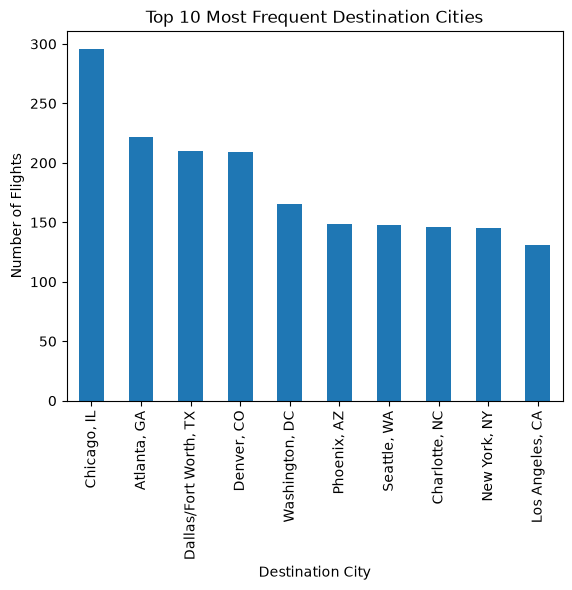

In [9]:
import matplotlib.pyplot as plt

destination_counts.head(10).plot(kind="bar")

plt.title("Top 10 Most Frequent Destination Cities")
plt.xlabel("Destination City")
plt.ylabel("Number of Flights")
plt.show()

**Which destination city is most common in the sample?**

Your answer:


Chicago, IL is the most common destination city in the sample, with 296 flights.

## What was the distribution of arrival delays?

Negative values represent early arrivals, zero represents an on-time arrival, and positive values represent late arrivals.

Create a histogram of `arrival_delay_minutes` using the default number of bins. Give the figure a descriptive title and label both axes.


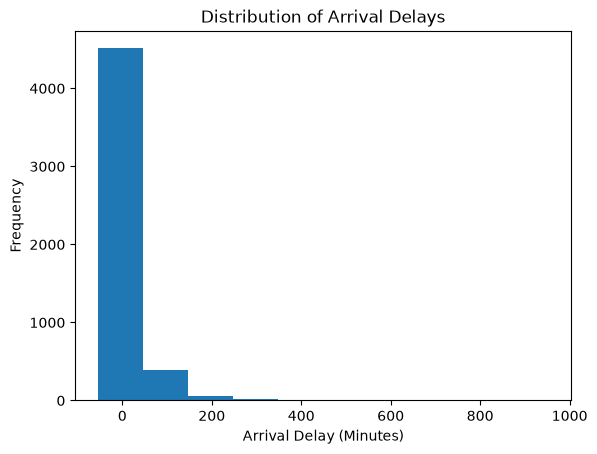

In [10]:
flights["arrival_delay_minutes"].plot(kind="hist")

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()

**Approximately what arrival-delay value appears most common?**

Your answer:


The most common arrival-delay value appears to be around 0 minutes, meaning many flights arrived close to their scheduled arrival time.

**What is the approximate range from the smallest to the largest arrival-delay value?**

Your answer:


The arrival delays range from approximately -50 minutes to nearly 1,000 minutes.

**Does the arrival-delay distribution appear symmetric or skewed?**

Your answer:


The distribution is strongly right-skewed. Most flights are concentrated near 0 minutes of delay, while a small number of flights have very large positive delays, creating a long tail to the right.

Display a numerical summary of `arrival_delay_minutes`.


In [11]:
flights["arrival_delay_minutes"].describe()

count    5000.000000
mean        6.098800
std        48.335493
min       -55.000000
25%       -16.000000
50%        -6.000000
75%        10.000000
max       953.000000
Name: arrival_delay_minutes, dtype: float64

Calculate and display the exact mode of `arrival_delay_minutes` using `.mode()`.


In [12]:
flights["arrival_delay_minutes"].mode()

0   -8
Name: arrival_delay_minutes, dtype: int64

**How closely did the calculated mode match the most common value you estimated from the histogram?**

Your answer:


The numerical summary showed a minimum of -55 minutes and a maximum of 953 minutes. This closely matched my estimate from the histogram of approximately -50 to 1,000 minutes.

**How closely did the minimum and maximum from `.describe()` match the range you estimated from the histogram?**

Your answer:


The calculated mode was -8 minutes. This was close to my estimate of around 0 minutes from the histogram because the histogram grouped nearby arrival-delay values into bins.

**Is the mean greater than, less than, or approximately equal to the median?**

Your answer:


The mean is greater than the median. The mean arrival delay is approximately 6.10 minutes, while the median is -6 minutes.

**How is the relationship between the mean and median connected to the histogram's shape?**

Your answer:


The mean is greater than the median because the distribution is strongly right-skewed. A small number of flights with very large positive delays pull the mean upward, while the median is less affected by these extreme values.

## Applying the principles: histogram bins

Re-create the arrival-delay histogram using exactly 5 bins.


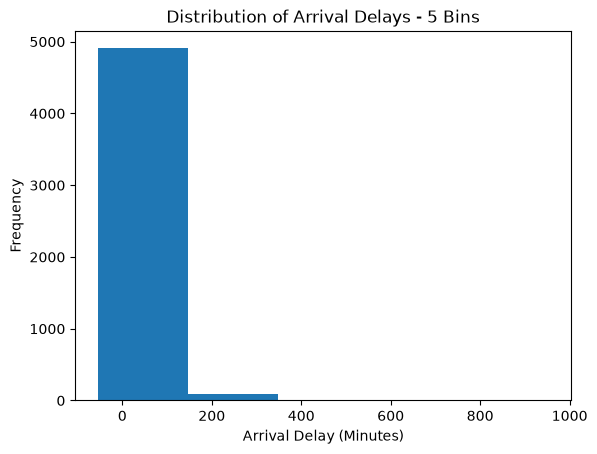

In [13]:
flights["arrival_delay_minutes"].plot(kind="hist", bins=5)

plt.title("Distribution of Arrival Delays - 5 Bins")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()

Re-create the arrival-delay histogram using exactly 25 bins.


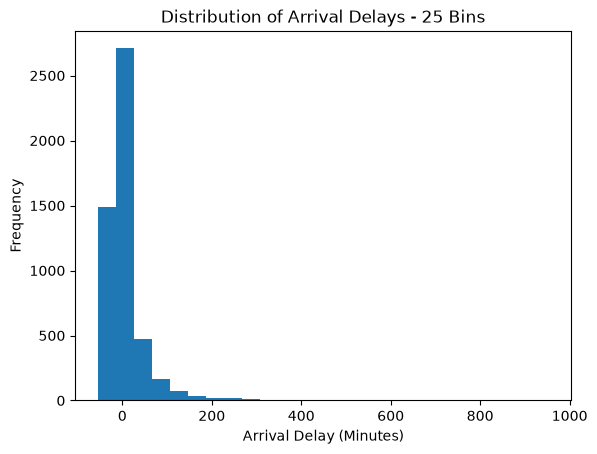

In [14]:
flights["arrival_delay_minutes"].plot(kind="hist", bins=25)

plt.title("Distribution of Arrival Delays - 25 Bins")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()

**What changed when the number of bins was reduced to 5?**

Your answer:


With only 5 bins, most of the arrival-delay values were grouped into one very large bar. This made the graph simpler, but it hid much of the detail in the distribution.

**What changed when the number of bins was increased to 25?**

Your answer:


With 25 bins, the smaller intervals showed much more detail. I could more clearly see that most flights were near zero or had relatively small delays, while a smaller number of flights had much larger delays extending to the right.

**Which bin setting communicates the distribution most clearly?**

Your answer:


The 25-bin histogram communicates the distribution most clearly because it shows the concentration of typical arrival delays and the long right tail without grouping most of the observations into a single bar.

## Applying the principles: a misleading vertical axis

Run both cells below and compare the figures.


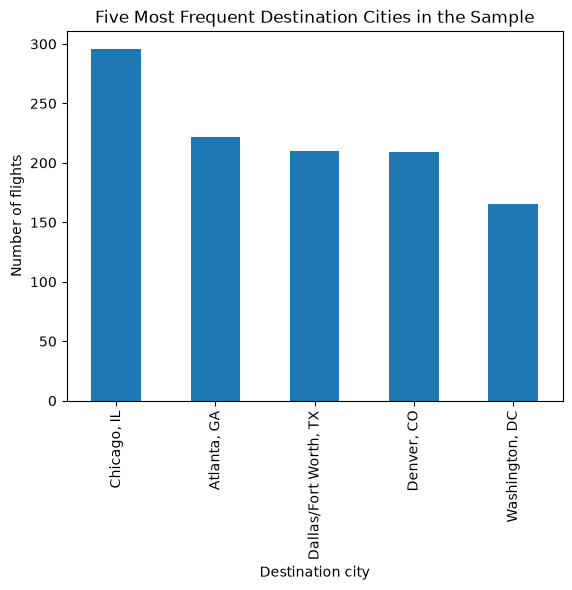

In [15]:
top_destinations = destination_counts.head(5)
top_destinations.plot(kind="bar")
plt.title("Five Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


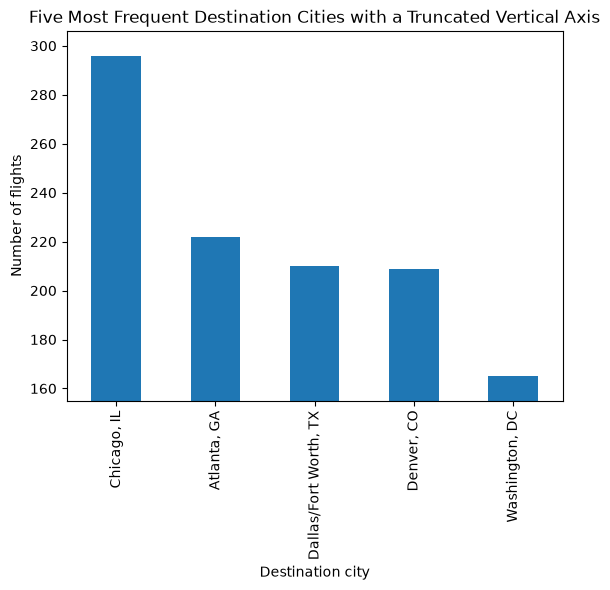

In [16]:
top_destinations.plot(kind="bar")
plt.ylim(top_destinations.min() - 10, top_destinations.max() + 10)
plt.title("Five Most Frequent Destination Cities with a Truncated Vertical Axis")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


**How does the truncated axis change the apparent differences among the destination cities?**

Your answer:


The truncated axis makes the differences among the destination cities appear much larger than they actually are. Because the vertical axis begins around 160 instead of 0, the differences in bar heights are visually exaggerated.

**Which chart communicates the counts more honestly?**

Your answer:


The first chart, with the vertical axis starting at 0, communicates the counts more honestly because the bar heights accurately represent the relative differences in the number of flights. The truncated chart can make the differences between the cities appear more dramatic than they are.

## Is this sample representative?

Review the dataset description at the top of the lab before answering these questions.


**What time period is represented by the source data?**

Your answer:


The source data represents reported domestic flights from May 2026.

**Which flights were eligible to be included in the sample?**

Your answer:


Completed, non-diverted domestic flights with recorded values for all five selected features were eligible to be included in the sample.

**Which flights and records were excluded before the sample was selected?**

Your answer:


Completed, non-diverted domestic flights with recorded values for all five selected features were eligible to be included in the sample.

**Does finding no missing values in the sample prove that the original BTS data had no missing values?**

Your answer:


No. Records with missing values were removed before the random sample was created, so having no missing values in the sample does not mean that the original BTS data had no missing values.

**Why should conclusions from this sample not automatically be generalized to canceled or diverted flights?**

Your answer:


Cancelled and diverted flights were excluded before the sample was selected. Therefore, the sample only represents eligible completed, non-diverted flights, and its results may not represent cancelled or diverted flights.

## Choosing a chart

Choose a histogram, bar chart, or pie chart for each question. Use the question and number of categories to justify your choice.


**Which chart would you use to show the frequency of each airline?**

Your answer:


I would use a bar chart because airline is a categorical feature. A bar chart makes it easy to compare the number of flights among the different airlines.

**Which chart would you use to show what proportion of sampled flights were early, on time, and delayed? Use arrival delays below 0, equal to 0, and above 0 minutes, respectively.**

Your answer:


I would use a pie chart because there are only three categories—early, on time, and delayed—and the question asks for the proportion of the whole sample in each category.

**Which chart would you use to show the distribution of flight distances?**

Your answer:


I would use a histogram because flight distance is a quantitative feature. A histogram groups the distances into intervals and shows the overall shape and distribution of the values.

## Explore a dataset of your own

Apply the same inspection and visualization process to a different dataset that interests you.

### 1. Find and describe your dataset

Start with [Kaggle Datasets](https://www.kaggle.com/datasets), the [UCI Machine Learning Repository](https://archive.ics.uci.edu/), or [Data.gov](https://catalog.data.gov/). You can also search a city or state open-data portal. Search for a topic you enjoy, such as sports, music, animals, transportation, or the environment.

Choose a manageable CSV file with a data dictionary (or equivalent feature documentation), at least one quantitative feature, and at least one categorical feature with a manageable number of categories. Use a different dataset from the flights and penguins already used in class. Save the file in this notebook's `data` folder.

Read the data dictionary before choosing your features. In a short paragraph, describe the dataset's subject, what one row represents, and its time period and geographic coverage if documented. Include its title, publisher or creator, a direct link to the dataset, and a link to the data dictionary. State when information is not documented instead of guessing.


**Dataset description and source links:**

Your answer:


I selected the PS4_GamesSales.csv file from the Video Games Sales Dataset published by SID_TWR on Kaggle. The dataset contains information about PlayStation 4 video games and their sales in different regions of the world. Each row represents a PS4 game and includes categorical features such as the game's genre and publisher, as well as quantitative features containing sales figures for North America, Europe, Japan, the rest of the world, and globally. The dataset also includes the game's release year. The documented PS4 data primarily covers games released during the PS4 generation. The dataset provides worldwide geographic coverage through its regional sales features.

Dataset title: Video Games Sales Dataset
Publisher/creator: SID_TWR
Dataset source: Kaggle – Video Games Sales Dataset
Data file: PS4_GamesSales.csv
Documentation/Data Dictionary: The Kaggle dataset page provides the dataset description and metadata.

### 2. Load the data and describe every feature

Load your CSV into a new DataFrame with a descriptive name ending in `_df`, such as `movies_df`, `weather_df`, or `animals_df`. Choose a name that describes your dataset and use it consistently throughout your analysis. Display its first five rows, shape, `.info()`, and `.isnull().sum()` to inspect its features, storage types, and missing values. Use a relative path so your notebook can run on another computer.


In [18]:
import pandas as pd

ps4_games_df = pd.read_csv(
    "data/PS4_GamesSales.csv",
    encoding="latin1"
)

display(ps4_games_df.head())

print("Shape:")
print(ps4_games_df.shape)

print("\nDataFrame Info:")
ps4_games_df.info()

print("\nMissing Values:")
print(ps4_games_df.isnull().sum())

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80


Shape:
(1034, 9)

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Game           1034 non-null   str    
 1   Year           825 non-null    float64
 2   Genre          1034 non-null   str    
 3   Publisher      825 non-null    str    
 4   North America  1034 non-null   float64
 5   Europe         1034 non-null   float64
 6   Japan          1034 non-null   float64
 7   Rest of World  1034 non-null   float64
 8   Global         1034 non-null   float64
dtypes: float64(6), str(3)
memory usage: 72.8 KB

Missing Values:
Game               0
Year             209
Genre              0
Publisher        209
North America      0
Europe             0
Japan              0
Rest of World      0
Global             0
dtype: int64


Complete the table below with **one row for every feature** in your dataset. Add as many rows as needed. Use the data dictionary to summarize what each feature means, including units or category-code meanings where relevant.

- **Data type:** quantitative or categorical; identify identifiers and date/time features explicitly when appropriate. A numeric identifier is not a quantitative measurement.
- **Data storage type:** the actual Pandas dtype shown by `.info()` or `.dtypes`, such as `int64`, `float64`, `object`, `str`, or `datetime64[ns]`.
- **Missing values:** the number reported for that feature, including 0 when there are none. Count missing values before removing records. If the dictionary defines special missing codes, such as -999 or "Unknown", explain how you handle those codes and make sure the counts reflect that decision.


| Feature | Description from the data dictionary (including units/codes) | Data type | Data storage type | Number of missing values |
| --- | --- | --- | --- | ---: |
|  |  |  |  |  |

**Missing-value codes or other data preparation, if applicable:**

Your answer:


The dataset contains 209 missing values in Year and 209 missing values in Publisher. The other features have no missing values. The CSV also required Latin-1 encoding to load correctly because it could not be decoded using the default UTF-8 encoding. No special numeric missing-value codes were identified. Missing values will be handled as needed for the specific features used in the analysis.

| Feature       | Description from the data dictionary (including units/codes)                                       | Data type        | Data storage type | Number of missing values |
| ------------- | -------------------------------------------------------------------------------------------------- | ---------------- | ----------------- | -----------------------: |
| Game          | Name/title of the PS4 video game                                                                   | Categorical      | str               |                        0 |
| Year          | Year the game was released                                                                         | Date/time (year) | float64           |                      209 |
| Genre         | Genre/category of the video game                                                                   | Categorical      | str               |                        0 |
| Publisher     | Company that published the video game                                                              | Categorical      | str               |                      209 |
| North America | Game sales in North America, in millions of units                                                  | Quantitative     | float64           |                        0 |
| Europe        | Game sales in Europe, in millions of units                                                         | Quantitative     | float64           |                        0 |
| Japan         | Game sales in Japan, in millions of units                                                          | Quantitative     | float64           |                        0 |
| Rest of World | Game sales outside the listed North American, European, and Japanese regions, in millions of units | Quantitative     | float64           |                        0 |
| Global        | Total worldwide game sales, in millions of units                                                   | Quantitative     | float64           |                        0 |


### 3. Visualize one quantitative feature

Choose one quantitative measurement and create an appropriate visualization of its distribution, such as a histogram. Include a descriptive title, a horizontal-axis label naming the feature and its units, and a vertical-axis label explaining what the heights represent. Explain any excluded missing values or other filtering. Do not use an ID number as your quantitative feature.


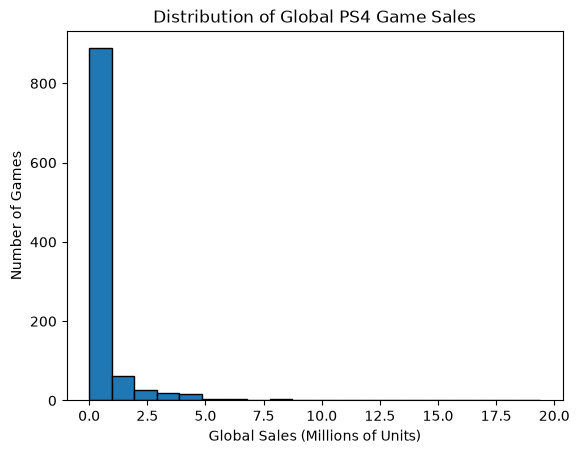

In [19]:
import matplotlib.pyplot as plt

ps4_games_df["Global"].plot(
    kind="hist",
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Global PS4 Game Sales")
plt.xlabel("Global Sales (Millions of Units)")
plt.ylabel("Number of Games")
plt.show()

**Which feature did you choose, and why is this chart appropriate?**

Your answer:

I chose Global sales, measured in millions of units. A histogram is appropriate because Global sales is a quantitative feature, and the histogram shows how the sales values are distributed across different ranges.

**In at least one complete sentence, describe what the figure tells you about this feature.** Refer to a visible pattern such as typical values, range, shape, or unusual observations, using values and units where possible. Describe the observations in your dataset without assuming they represent a larger population.

Your interpretation:
The distribution of global sales is strongly right-skewed. Most games in this dataset have global sales near the lower end of the range, while a small number have much higher sales. The values range from near 0 to almost 20 million units, creating a long right tail.

### 4. Visualize one categorical feature

Choose a categorical feature and create an appropriate visualization of its distribution. A bar chart of category counts is a good choice; use `.value_counts()` to obtain numeric bar heights from text labels. Include a descriptive title and labels identifying the categories and counts or percentages on the axes. If you choose a pie chart for a small number of categories, label the slices and their shares instead of axes. Explain any excluded missing values or categories, and identify the denominator if you use percentages.


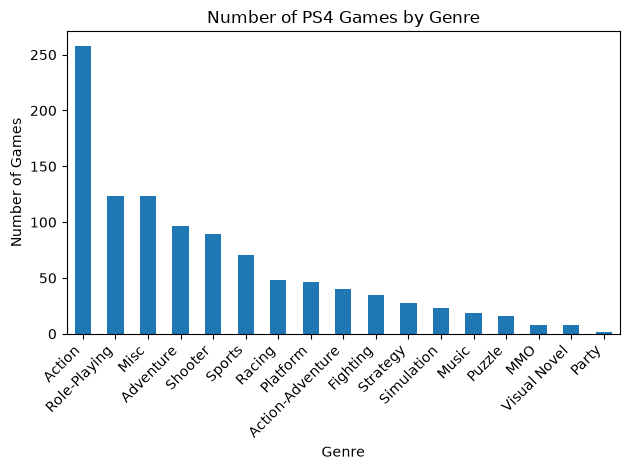

In [20]:
genre_counts = ps4_games_df["Genre"].value_counts()

genre_counts.plot(kind="bar")

plt.title("Number of PS4 Games by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Which feature did you choose, and why is this chart appropriate?**

Your answer:
I chose Genre as the categorical feature. A bar chart is appropriate because Genre contains distinct categories, and the bar heights make it easy to compare the number of games in each genre.

**In at least one complete sentence, describe what the figure tells you about this feature.** Identify a meaningful pattern, such as the most or least common category or a difference in counts or shares. Support the interpretation with evidence visible in your figure.

Your interpretation:
Action is the most common genre in this dataset, with about 260 games, which is more than twice the number of Role-Playing or Misc games at about 125 each. Party is the least common genre, with only a few games represented.


## Reflect on AI assistance

Complete one of the following statements.

**If you used an AI tool:**

- Tool used:
- What I asked it to help with:
- One suggestion I checked against my code, chart, or output:
- What I accepted, modified, or rejected—and why:

**If you did not use an AI tool:**

- I did not use an AI tool for this assignment.
- One resource or troubleshooting strategy I used instead was:


Your response:


Tool used: ChatGPT
What I asked it to help with: I used ChatGPT to help with Pandas and Matplotlib syntax, selecting appropriate visualizations, and interpreting the results of my charts.
One suggestion I checked against my code, chart, or output: ChatGPT suggested using a bar chart with value_counts() to visualize the Genre feature. I ran the code and checked the resulting chart to confirm that the categories and their frequencies were displayed correctly.
What I accepted, modified, or rejected—and why: I accepted the bar chart because Genre is categorical and the chart clearly compared the number of games in each category. I also checked the interpretation against the completed chart before using it to make sure the statements were supported by my actual dataset.

## Submission checklist

- All code cells run from top to bottom without errors.
- The destination-city bar chart has a descriptive title and labeled axes.
- The default, 5-bin, and 25-bin arrival-delay histograms are included and labeled.
- Both vertical-axis demonstrations are included.
- Every question has one response in its own answer cell.
- The sample questions are answered using the dataset documentation.
- The chosen dataset and its data dictionary are linked and described.
- The feature table includes a description, data type, storage type, and missing-value count for every feature.
- One quantitative and one categorical feature have appropriate labeled visualizations and at least one sentence of interpretation each.
- The chosen CSV is included in the `data` folder with the submitted notebook, and relative paths work.
- The AI-use reflection is complete and honest.
